# Basic Ecommerce Funnel Analysis
This is a simple ecommerce funnel analysis. I followed a tutorial for the SQL commands and to get the general idea of what sorts of questions to try and answer with our analysis. However, I took it upon myself to end up making this notebook to lead through the process and then also display our findings with some graphs that give a visual representation of what exactly is going on.

In [1]:
import pandas as pd
import sqlite3
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("user_events.csv")

conn = sqlite3.connect("database.sqlite")

df.to_sql("user_events", conn, index=False, if_exists="replace")

# Check tables
tables = pd.read_sql("""
SELECT name 
FROM sqlite_master
WHERE type='table';
""", conn)

print(tables)

print("\nSetup complete!")
df.head()

          name
0  user_events

Setup complete!


,event_id,user_id,event_type,event_date,product_id,amount,traffic_source
0,8490,5024,page_view,2025-12-30 04:58:24.517006,205,NaN,social
1,2296,1713,page_view,2025-12-30 05:10:26.276377,201,NaN,organic
2,3896,2558,page_view,2025-12-30 05:11:09.001887,404,NaN,organic
3,2297,1713,add_to_cart,2025-12-30 05:13:26.276377,201,NaN,organic
4,2298,1713,checkout_start,2025-12-30 05:16:26.276377,201,NaN,organic


# First Analysis - Conversion Funnel
The first analysis that is being performed here is a conversion funnel. The goal of this is to see how many people end up actually getting all the way through until the end and make a purchase. Not many people end up actually adding anything to their cart which is not abnormal. It is very common for people to simply window shop. But, once someone does end up adding something to their cart we can follow the process and see that over half of the people that add an item to their cart end up making a purchase.

In [2]:
query = """
WITH funnel_stages AS (
    SELECT
        COUNT(DISTINCT CASE WHEN event_type = 'page_view' THEN user_id END) AS stage_1_views,
        COUNT(DISTINCT CASE WHEN event_type = 'add_to_cart' THEN user_id END) AS stage_2_cart,
        COUNT(DISTINCT CASE WHEN event_type = 'checkout_start' THEN user_id END) AS stage_3_checkout,
        COUNT(DISTINCT CASE WHEN event_type = 'payment_info' THEN user_id END) AS stage_4_payment,
        COUNT(DISTINCT CASE WHEN event_type = 'purchase' THEN user_id END) AS stage_5_purchase
    FROM user_events
)

SELECT
    stage_1_views,
    stage_2_cart,
    ROUND(stage_2_cart * 100.0 / stage_1_views, 2) AS view_to_cart_rate,
    stage_3_checkout,
    ROUND(stage_3_checkout * 100.0 / stage_2_cart, 2) AS cart_to_checkout_rate,
    stage_4_payment,
    ROUND(stage_4_payment * 100.0 / stage_3_checkout, 2) AS checkout_to_payment_rate,
    stage_5_purchase,
    ROUND(stage_5_purchase * 100.0 / stage_4_payment, 2) AS payment_to_purchase_rate,
    ROUND(stage_5_purchase * 100.0 / stage_1_views, 2) AS overall_conversion_rate
FROM funnel_stages;
"""

funnel_df = pd.read_sql(query, conn)

funnel_df

,stage_1_views,stage_2_cart,view_to_cart_rate,stage_3_checkout,cart_to_checkout_rate,stage_4_payment,checkout_to_payment_rate,stage_5_purchase,payment_to_purchase_rate,overall_conversion_rate
0,5000,1553,31.06,1103,71.02,899,81.5,826,91.88,16.52


In [3]:
funnel_graph_df = pd.DataFrame({
    "stage": [
        "Page View",
        "Add to Cart",
        "Checkout Started",
        "Payment Info",
        "Purchase"
    ],
    "users": [
        funnel_df["stage_1_views"][0],
        funnel_df["stage_2_cart"][0],
        funnel_df["stage_3_checkout"][0],
        funnel_df["stage_4_payment"][0],
        funnel_df["stage_5_purchase"][0]
    ]
})

funnel_graph_df

,stage,users
0,Page View,5000
1,Add to Cart,1553
2,Checkout Started,1103
3,Payment Info,899
4,Purchase,826


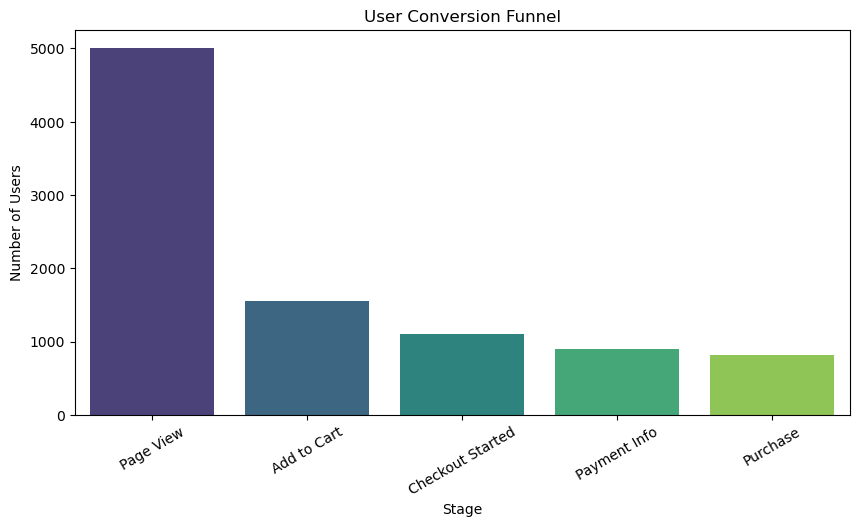

In [4]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=funnel_graph_df,
    x="stage",
    y="users",
    hue="stage",
    palette="viridis",
    legend=False
)

plt.xticks(rotation=30)
plt.title("User Conversion Funnel")
plt.xlabel("Stage")
plt.ylabel("Number of Users")

plt.show()

# Second Analysis - User Journey Through Time
The goal of this second anylsis is to see how long it takes a customer to move through the different stages of the purchasing process. There are no abnormalities detected. All the times are reasonable in imagining how long someone might look around the shop to see if they want to buy anything else or to also input payment information. No red flags.

In [5]:
query = """
WITH user_journey AS (
  SELECT
    user_id,
    MIN(CASE WHEN event_type = 'page_view' THEN event_date END) AS view_time,
    MIN(CASE WHEN event_type = 'add_to_cart' THEN event_date END) AS cart_time,
    MIN(CASE WHEN event_type = 'purchase' THEN event_date END) AS purchase_time

  FROM user_events
  GROUP BY user_id
  HAVING MIN(CASE WHEN event_type = 'purchase' THEN event_date END) IS NOT NULL
)

SELECT
  COUNT(*) AS converted_users,
  ROUND(AVG(unixepoch(cart_time) - unixepoch(view_time)) / 60.0,2) AS avg_view_to_cart_minutes,
  ROUND(AVG(unixepoch(purchase_time) - unixepoch(cart_time)) / 60.0,2) AS avg_cart_to_purchase_minutes,
  ROUND(AVG(unixepoch(purchase_time) - unixepoch(view_time)) / 60.0,2) AS avg_total_journey_minutes
FROM user_journey;
"""

user_journey_df = pd.read_sql(query, conn)

user_journey_df

,converted_users,avg_view_to_cart_minutes,avg_cart_to_purchase_minutes,avg_total_journey_minutes
0,826,11.16,13.47,24.63


In [6]:
journey_graph_df = pd.DataFrame({
    "stage": [
        "From View to Cart",
        "From Cart to Purchase",
        "Total Journey"
    ],
    "time": [
        user_journey_df["avg_view_to_cart_minutes"][0],
        user_journey_df["avg_cart_to_purchase_minutes"][0],
        user_journey_df["avg_total_journey_minutes"][0]
    ]
})

journey_graph_df

,stage,time
0,From View to Cart,11.16
1,From Cart to Purchase,13.47
2,Total Journey,24.63


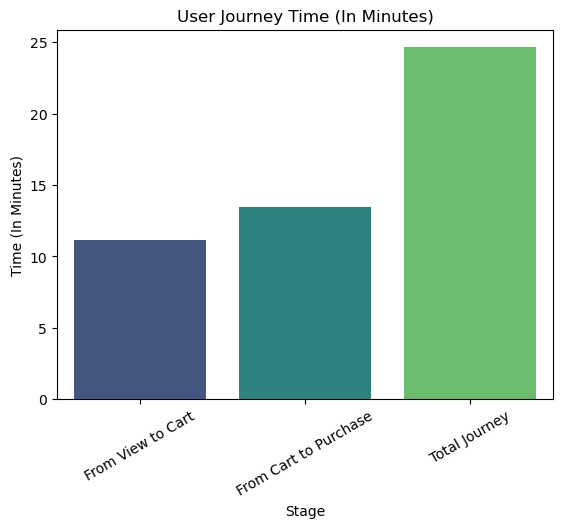

In [7]:
sns.barplot(
    data=journey_graph_df,
    x="stage",
    y="time",
    hue="stage",
    palette="viridis",
    legend=False
)

plt.xticks(rotation=30)
plt.title("User Journey Time (In Minutes)")
plt.xlabel("Stage")
plt.ylabel("Time (In Minutes)")

plt.show()

# Third Analysis - Revenue
The purpose of this final analysis is to see what sort of revenue is being generated per view and per customer. The reason this is important is because we can compare how much money is being made per purchase and compare it to the CAC (customer acquisition cost) to see if money is being made or lost. Since this is a hypothetical situation there is no CAC to compare to. But we can see that currently the revenue per customer is $106.51. If the CAC was higher than that or getting close it would make sense to consider some ways to try and bring that down significantly.

In [8]:
query = """
WITH funnel_revenue AS (
  SELECT
    COUNT(DISTINCT CASE WHEN event_type = 'page_view' THEN user_id END) AS total_visitors,
    COUNT(DISTINCT CASE WHEN event_type = 'purchase' THEN user_id END) AS total_buyers,
    SUM(CASE WHEN event_type = 'purchase' THEN amount END) AS total_revenue,
    COUNT(CASE WHEN event_type = 'purchase' THEN 1 END) AS total_orders

  FROM user_events
)

SELECT
  total_visitors,
  total_buyers,
  total_orders,
  ROUND(total_revenue,2) as total_revenue,
  ROUND(total_revenue / total_orders, 2) AS avg_order_value,
  ROUND(total_revenue / total_buyers, 2) AS revenue_per_buyer,
  ROUND(total_revenue / total_visitors, 2) AS revenue_per_visitor

FROM funnel_revenue;
"""

funnel_revenue_df = pd.read_sql(query, conn)

funnel_revenue_df

,total_visitors,total_buyers,total_orders,total_revenue,avg_order_value,revenue_per_buyer,revenue_per_visitor
0,5000,826,826,87975.11,106.51,106.51,17.6


In [9]:
revenue_graph_df = pd.DataFrame({
    "type": [
        "Revenue Per Visitor",
        "Revenue Per Buyer",
        "Average Order Revenue"
    ],
    "revenue": [
        funnel_revenue_df["revenue_per_visitor"][0],
        funnel_revenue_df["revenue_per_buyer"][0],
        funnel_revenue_df["avg_order_value"][0]
    ]
})

revenue_graph_df

,type,revenue
0,Revenue Per Visitor,17.60
1,Revenue Per Buyer,106.51
2,Average Order Revenue,106.51


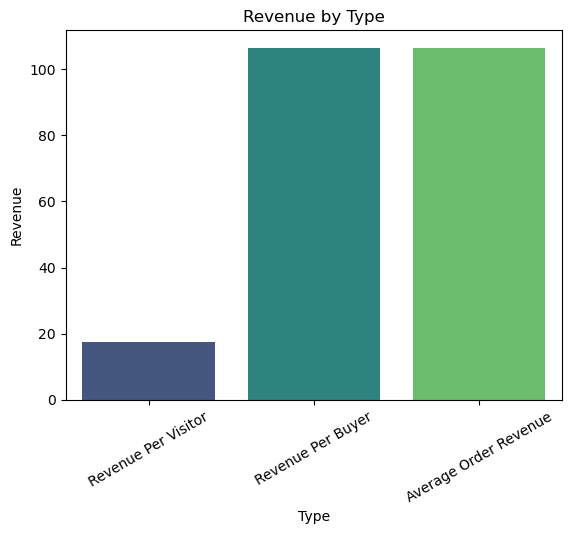

In [10]:
sns.barplot(
    data=revenue_graph_df,
    x="type",
    y="revenue",
    hue="type",
    palette="viridis",
    legend=False
)

plt.xticks(rotation=30)
plt.title("Revenue by Type")
plt.xlabel("Type")
plt.ylabel("Revenue")

plt.show()